In [10]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [11]:
from google.colab import files

uploaded = files.upload()
DOSYA_YOLU = list(uploaded.keys())[0]
print("Yüklenen dosya:", DOSYA_YOLU)

Saving y_amazon-google-large.csv to y_amazon-google-large.csv
Yüklenen dosya: y_amazon-google-large.csv


In [12]:
SECILEN_ID = 0

ham = pd.read_csv(DOSYA_YOLU)
ham = ham[ham["unique_id"] == SECILEN_ID].copy()
ham["ds"] = pd.to_datetime(ham["ds"])
ham = ham.sort_values("ds").reset_index(drop=True)

ham["saat"] = ham["ds"].dt.hour
ham["haftanin_gunu"] = ham["ds"].dt.dayofweek
ham["ay"] = ham["ds"].dt.month
ham["hafta_sonu_mu"] = (ham["haftanin_gunu"] >= 5).astype(int)
ham["lag_1"] = ham["y"].shift(1)
ham["lag_24"] = ham["y"].shift(24)
ham["lag_168"] = ham["y"].shift(168)
ham["hareketli_ort_24"] = ham["y"].shift(1).rolling(window=24).mean()

frame = ham.drop(columns=["ds", "unique_id", "Unnamed: 0"]).dropna().reset_index(drop=True)
frame.head(2)

,y,saat,haftanin_gunu,ay,hafta_sonu_mu,lag_1,lag_24,lag_168,hareketli_ort_24
0,8.0,8,2,1,0,10.0,3.0,6.0,17.750000
1,2.0,9,2,1,0,8.0,3.0,0.0,17.958333


In [13]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12832 entries, 0 to 12831
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   y                 12832 non-null  float64
 1   saat              12832 non-null  int32  
 2   haftanin_gunu     12832 non-null  int32  
 3   ay                12832 non-null  int32  
 4   hafta_sonu_mu     12832 non-null  int64  
 5   lag_1             12832 non-null  float64
 6   lag_24            12832 non-null  float64
 7   lag_168           12832 non-null  float64
 8   hareketli_ort_24  12832 non-null  float64
dtypes: float64(5), int32(3), int64(1)
memory usage: 752.0 KB


In [14]:
X_reg = frame.drop("y", axis=1)
y_reg = frame["y"]

In [15]:
y_reg

,y
0,8.0
1,2.0
2,4.0
3,8.0
4,8.0
...,...
12827,23.0
12828,23.0
12829,20.0
12830,23.0


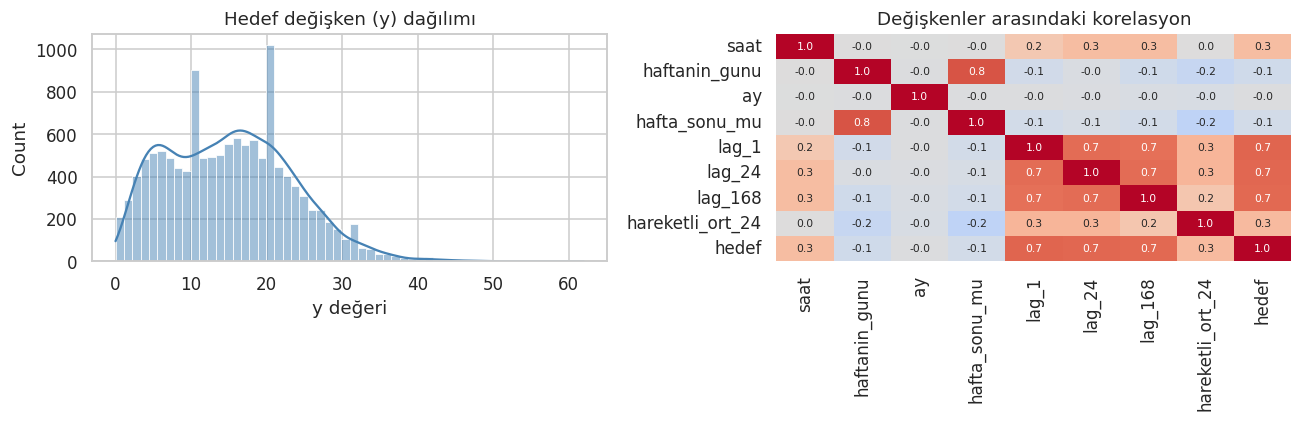

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_reg, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Hedef değişken (y) dağılımı")
axes[0].set_xlabel("y değeri")

corr = pd.concat([X_reg, y_reg.rename("hedef")], axis=1).corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            ax=axes[1], cbar=False, annot_kws={"size": 7})
axes[1].set_title("Değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

In [18]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

10265


2567

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
linear = LinearRegression().fit(Xr_train, yr_train)

def regresyon_raporu(model, X, y, ad):
    tahmin = model.predict(X)
    return {
        "Model": ad,
        "Mae": mean_absolute_error(y, tahmin),
        "mse": mean_squared_error(y, tahmin),
        "rmse": np.sqrt(mean_squared_error(y, tahmin)),
        "r2": r2_score(y, tahmin)
    }

sonuc = pd.DataFrame([
    regresyon_raporu(baseline, Xr_test, yr_test, "Baseline"),
    regresyon_raporu(linear, Xr_test, yr_test, "Linear")
]).set_index("Model").round(3)
sonuc

,Mae,mse,rmse,r2
Model,,,,
Baseline,6.932,71.388,8.449,-0.000
Linear,3.751,24.173,4.917,0.661


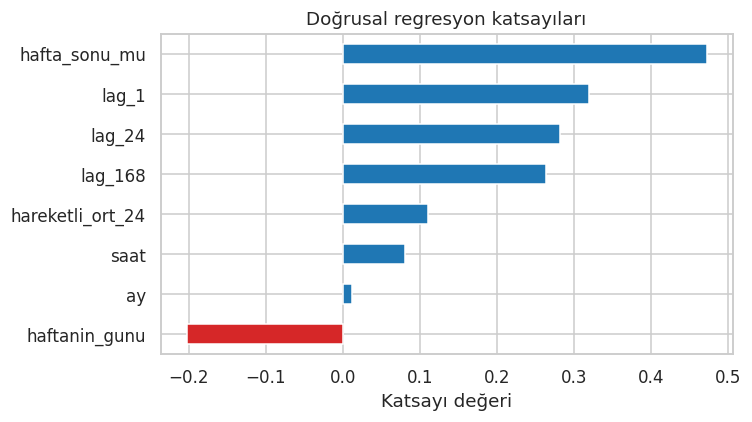

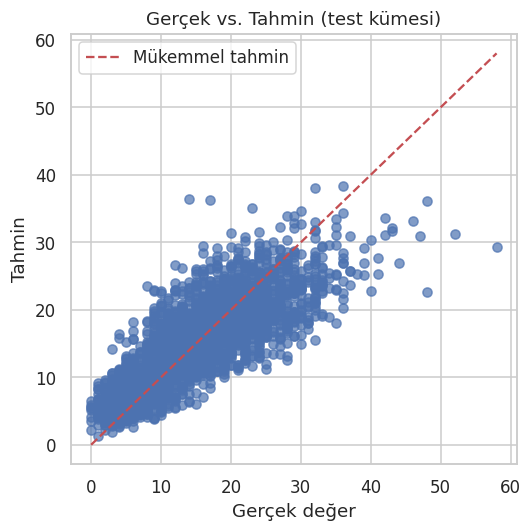

In [20]:
katsayilar = pd.Series(linear.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()

tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.7)
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modeller = {
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0))
}

satirlar = []
for ad, m in modeller.items():
    m.fit(Xr_train, yr_train)
    satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,3.751,24.173,4.917,0.661
Ridge,3.751,24.173,4.917,0.661
Lasso,3.953,26.079,5.107,0.635


In [22]:
lasso = modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_, index=X_reg.columns).round(2).to_frame("Lasso değişkenler").T

,saat,haftanin_gunu,ay,hafta_sonu_mu,lag_1,lag_24,lag_168,hareketli_ort_24
Lasso değişkenler,0.0,-0.0,0.0,-0.0,2.32,2.09,1.88,0.0


In [23]:
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'Lasso'])


In [24]:
sutunlar = ["sepal_length", "sepal_width", "petal_length", "petal_width", "sinif"]
iris = pd.read_csv("iris.data", header=None, names=sutunlar)

X_clf = iris.drop(columns=["sinif"])
y_clf = iris["sinif"]
X_clf.head(2)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [25]:
print("Sınıf dağılımı:")
print(y_clf.value_counts())
X_clf.describe().T.round(2)

Sınıf dağılımı:
sinif
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.05,0.43,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.76,1.76,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5


In [26]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=SEED)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train),
    "Logistic": LogisticRegression(max_iter=1000).fit(Xc_train, yc_train),
    "KNN": KNeighborsClassifier().fit(Xc_train, yc_train),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED).fit(Xc_train, yc_train),
    "Rastgele orman": RandomForestClassifier(random_state=SEED).fit(Xc_train, yc_train)
}

satirlar = []
for ad, m in siniflandiricilar.items():
    m.fit(Xc_train, yc_train)
    satirlar.append({
        "Model": ad,
        "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test))
    })

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.342,0.3
Logistic,0.975,1.0
KNN,0.967,1.0
Karar ağacı,1.000,1.0
Rastgele orman,1.000,1.0


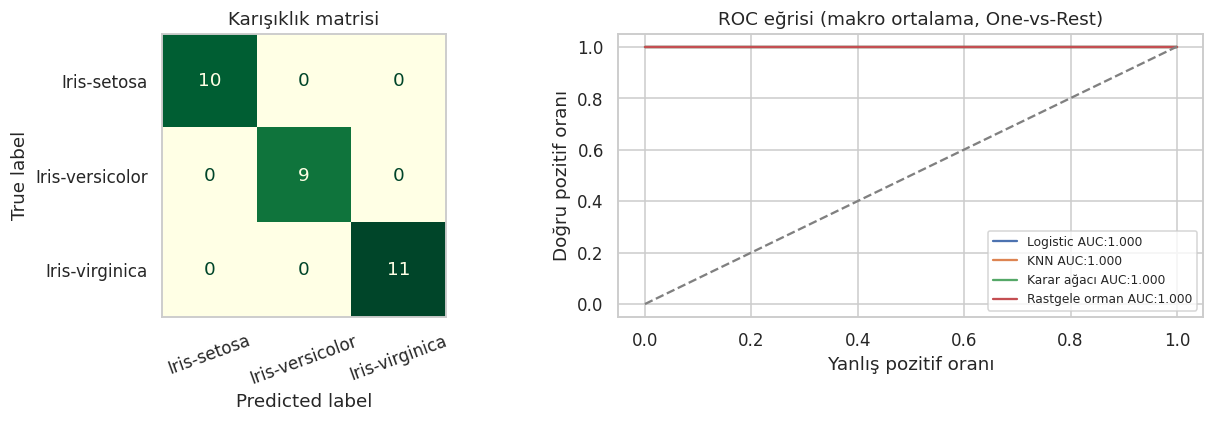

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

siniflar = sorted(y_clf.unique())
y_test_bin = label_binarize(yc_test, classes=siniflar)

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(yc_test, tahmin, display_labels=siniflar, cmap="YlGn", ax=axes[0], colorbar=False)
axes[0].set_title("Karışıklık matrisi")
axes[0].grid(False)
axes[0].tick_params(axis="x", rotation=20)

fpr_ortak = np.linspace(0, 1, 100)
for ad in ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]:
    olasilik = siniflandiricilar[ad].predict_proba(Xc_test)
    tpr_toplam = np.zeros_like(fpr_ortak)
    for i in range(len(siniflar)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], olasilik[:, i])
        tpr_toplam += np.interp(fpr_ortak, fpr, tpr)
    tpr_ortalama = tpr_toplam / len(siniflar)
    auc_makro = roc_auc_score(yc_test, olasilik, multi_class="ovr", average="macro")
    axes[1].plot(fpr_ortak, tpr_ortalama, label=f"{ad} AUC:{auc_makro:.3f}")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Yanlış pozitif oranı")
axes[1].set_ylabel("Doğru pozitif oranı")
axes[1].set_title("ROC eğrisi (makro ortalama, One-vs-Rest)")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

satirlar = []
for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    satirlar.append({"Model": ad, "Ortalama skor": skorlar.mean(), "Standart sapma": skorlar.std()})

cv_sonuc = pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
KNN,0.958,0.026
Logistic,0.950,0.049
Karar ağacı,0.933,0.050
Rastgele orman,0.933,0.033
Baseline,0.333,0.000


In [31]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

opt = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("best parametre:", opt.best_params_)
print(f"en iyi cv:{opt.best_score_:3f}")

best parametre: {'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'distance'}
en iyi cv:0.966667
